# FAGCN — Threshold Tuning & Evaluation

Looks up the best run from MLflow experiment `static-gnn-fagcn` by `best_val_ap`, loads the saved `.pth` from `saved_models/`, tunes the decision threshold on the **val set** by maximising MCC, then reports all metrics on the **test set**.

## Imports & setup

In [1]:
import os
import sys
import warnings
import logging

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    recall_score,
    precision_score,
    roc_curve,
    precision_recall_curve,
)
from utils import *
from torch_geometric.loader import NeighborLoader
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
from namespaces import DA
from dgraphfin import load_dgraphfin

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARN)

/home/mai/notebooks/final_thesis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.chdir('/home/mai/notebooks/final_thesis/')
sys.path.insert(0, './src')

In [3]:
from models import GATModel, GraphSAGEModel, GATv2Model, FAGCNModel

## Find best run in MLflow

In [4]:
# ── Look up the best run from the training experiment by val_auc ─────────────
experiment_name = 'static-gnn-fagcn'
metric_name     = 'best_val_ap'

exp  = mlflow.get_experiment_by_name(experiment_name)
runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    order_by=[f"metrics.{metric_name} DESC"],
    max_results=1,
)

best_run    = runs.iloc[0]
best_run_id = best_run["run_id"]

print("Best run ID :", best_run_id)
print(f"Best {metric_name} :", best_run[f"metrics.{metric_name}"])

Best run ID : f4ef218a6bb0464cb2191bf29b87ec0d
Best best_val_ap : 0.23270186724751785


## Recover model path from logged params

In [5]:
# Recover the model save path from the params logged by the training script
# (training script calls mlflow.log_params(vars(args)), so all CLI args are stored)
prefix = best_run["params.prefix"]
model  = best_run["params.model"]
data   = best_run["params.data"]

model_path  = f'./saved_models/{experiment_name}-{prefix}-{data}.pth'

print("Model path  :", model_path)

Model path  : ./saved_models/static-gnn-fagcn-fagcn_run5-DGraphFin.pth


## Config

In [6]:
# ── Architecture config — must match the values used during training ──────────
NODE_DIM     = int(best_run['params.node_dim'])
FEAT_AUGMENT = (best_run['params.feat_augment'] == 'True')
NUM_LAYER    = int(best_run['params.n_layer'])
NUM_NEIGHBOR = int(best_run['params.n_neighbor'])
HEADS        = int(best_run['params.n_head'])       # attention heads (GAT / GATv2 only)
EPS          = float(best_run['params.eps'])        # eps (FAGCN only)
BATCH_SIZE   = int(best_run['params.bs']) * 2    # inference only — no grad, can be large
NUM_WORKERS  = int(best_run['params.num_workers'])
N_THRESHOLD  = 500     # number of candidate thresholds swept on val set
DROP_OUT     = float(best_run['params.drop_out'])
GPU          = int(best_run['params.gpu'])
FOLD         = 0
DATA_DIR     = './datasets'

## Load data & model weights

In [9]:
device = torch.device(f'cuda:{GPU}' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

bundle = load_dgraphfin(data_dir=DATA_DIR, fold=FOLD, to_undirected=False)
et = torch.tensor(np.load(os.path.join(DATA_DIR, 'DGraphFin', 'dgraphfinv2_edge_timestamp.npy')), dtype=torch.float32)
nt = torch.tensor(np.load(os.path.join(DATA_DIR, 'DGraphFin', 'dgraphfinv2_node_timestamp.npy')), dtype=torch.float32)

graph         = bundle.graph
train_idx     = bundle.train_idx
val_idx       = bundle.val_idx
test_idx      = bundle.test_idx
node_feat_dim = bundle.node_feat_dim

if FEAT_AUGMENT:
    graph.x       = augment_static_features(graph.x, graph.edge_index, train_idx, et, nt)
    node_feat_dim = graph.x.shape[1]

print(f'Graph : {graph.num_nodes:,} nodes | {graph.num_edges:,} edges')
print(f'Val   : {len(val_idx):,} nodes')
print(f'Test  : {len(test_idx):,} nodes')

# Build model and load weights from saved_models/
if model == 'sage':
    gnn = GraphSAGEModel(node_feat_dim, NODE_DIM, NUM_LAYER, DROP_OUT).to(device)
elif model == 'gat':
    gnn = GATModel(node_feat_dim, NODE_DIM, NUM_LAYER, HEADS, DROP_OUT).to(device)
elif model == 'gatv2':
    gnn = GATv2Model(node_feat_dim, NODE_DIM, NUM_LAYER, HEADS, DROP_OUT).to(device)
else:
    gnn = FAGCNModel(node_feat_dim, NODE_DIM, NUM_LAYER, DROP_OUT, EPS).to(device)

gnn.load_state_dict(torch.load(model_path, map_location=device))
gnn.eval()
print(f'Loaded  : {model_path}')
print(f'Params  : {sum(p.numel() for p in gnn.parameters()):,}')

Device: cuda:0
Graph : 3,700,550 nodes | 4,300,999 edges
Val   : 183,862 nodes
Test  : 183,840 nodes
Loaded  : ./saved_models/static-gnn-fagcn-fagcn_run5-DGraphFin.pth
Params  : 30,465


## NeighborLoaders

In [10]:
# num neighbors per layer
if NUM_LAYER == 1:
    num_neighbors = [NUM_NEIGHBOR]
# elif NUM_LAYER == 2:
#     num_neighbors = [NUM_NEIGHBOR, 5]
else:
    # step = max(1, (NUM_NEIGHBOR - 5) // (NUM_LAYER - 1))
    # num_neighbors = [max(5, NUM_NEIGHBOR - i * step) for i in range(NUM_LAYER)]
    num_neighbors = [NUM_NEIGHBOR] * NUM_LAYER
print('NeighborLoader fanouts:', num_neighbors)

val_loader = NeighborLoader(
    graph,
    num_neighbors = num_neighbors,
    batch_size    = BATCH_SIZE,
    input_nodes   = val_idx,
    shuffle       = False,
    num_workers   = NUM_WORKERS,
)

test_loader = NeighborLoader(
    graph,
    num_neighbors = num_neighbors,
    batch_size    = BATCH_SIZE,
    input_nodes   = test_idx,
    shuffle       = False,
    num_workers   = NUM_WORKERS,
)

NeighborLoader fanouts: [10, 10, 10, 10]


## Inference helper

In [11]:
@torch.no_grad()
def get_scores(loader, desc='Inference'):
    all_scores, all_labels = [], []
    for batch in tqdm(loader, desc=desc):
        batch      = batch.to(device, non_blocking=True)
        batch_size = batch.batch_size
        logits     = gnn(batch.x, batch.edge_index, batch_size)
        scores     = torch.sigmoid(logits).cpu().numpy()
        labels     = batch.y[:batch_size].cpu().numpy()
        all_scores.append(scores)
        all_labels.append(labels)
    return np.concatenate(all_scores), np.concatenate(all_labels)

## Cutoff selection — maximise MCC on val set

Val inference: 100%|██████████| 180/180 [00:02<00:00, 64.61it/s] 


Best cutoff : 0.7635
Val MCC     : 0.3704


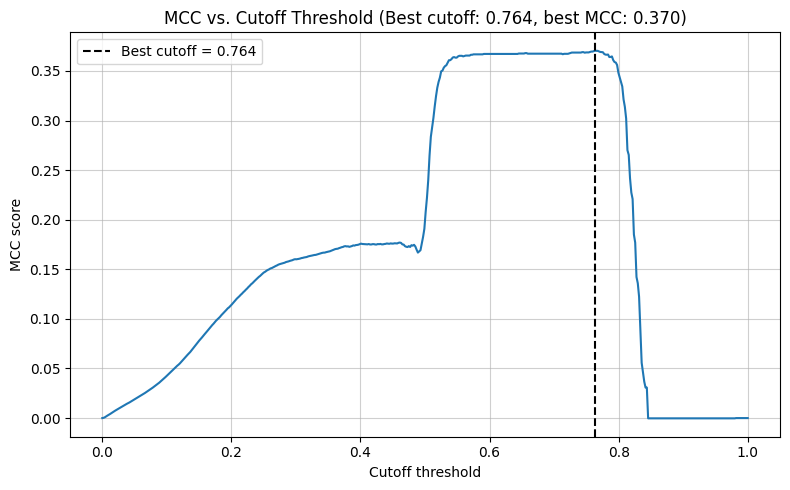

In [12]:
# ── Cutoff selection to maximise MCC (val set) ───────────────────────────────
y_prob_val, y_true_val = get_scores(val_loader, desc='Val inference')

thresholds = np.linspace(0, 1, N_THRESHOLD)
mcc_scores = []
for t in thresholds:
    y_pred = (y_prob_val >= t).astype(int)
    mcc_scores.append(matthews_corrcoef(y_true_val, y_pred))

best_idx       = np.argmax(mcc_scores)
best_threshold = thresholds[best_idx]
best_mcc       = mcc_scores[best_idx]

print(f'Best cutoff : {best_threshold:.4f}')
print(f'Val MCC     : {best_mcc:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(thresholds, mcc_scores)
plt.axvline(best_threshold, ls='--', color='k',
            label=f'Best cutoff = {best_threshold:.3f}')
plt.title(f'MCC vs. Cutoff Threshold (Best cutoff: {best_threshold:.3f}, best MCC: {best_mcc:.3f})')
plt.xlabel('Cutoff threshold')
plt.ylabel('MCC score')
plt.legend()
plt.grid(True, axis='both', alpha=0.6)
plt.tight_layout()
plt.show()

## Test-set evaluation

In [13]:
# ── Apply best threshold to test set ─────────────────────────────────────────
y_prob, y_true = get_scores(test_loader)
y_pred = (y_prob >= best_threshold).astype(int)

auc = roc_auc_score(y_true, y_prob)
ap  = average_precision_score(y_true, y_prob)
f1  = f1_score(y_true, y_pred,  zero_division=0)
mcc = matthews_corrcoef(y_true, y_pred)
rc  = recall_score(y_true, y_pred, zero_division=0)
pr  = precision_score(y_true, y_pred, zero_division=0)
rc_at_125 = recall_at_top_n_percent(y_true, y_prob, n_percent=1.25)
pr_at_125 = precision_at_top_n_percent(y_true, y_prob, n_percent=1.25)

rc_at_127 = recall_at_top_n_percent(y_true, y_prob, n_percent=1.27)
pr_at_127 = precision_at_top_n_percent(y_true, y_prob, n_percent=1.27)

print(f'AUC       : {auc:.4f}')
print(f'AP        : {ap:.4f}')
print(f'F1        : {f1:.4f}')
print(f'MCC       : {mcc:.4f}')
print(f'Recall    : {rc:.4f}')
print(f'Precision : {pr:.4f}')
print(f'Recall at top 1.25% : {rc_at_125:.4f}')
print(f'Precision at top 1.25% : {pr_at_125:.4f}')

print(f'Recall at top 1.27% : {rc_at_127:.4f}')
print(f'Precision at top 1.27% : {pr_at_127:.4f}')

Inference: 100%|██████████| 180/180 [00:02<00:00, 84.33it/s] 


AUC       : 0.8993
AP        : 0.2489
F1        : 0.2855
MCC       : 0.3853
Recall    : 0.1702
Precision : 0.8839
Recall at top 1.25% : 0.2343
Precision at top 1.25% : 0.2372
Recall at top 1.27% : 0.2352
Precision at top 1.27% : 0.2343


## ROC Curve

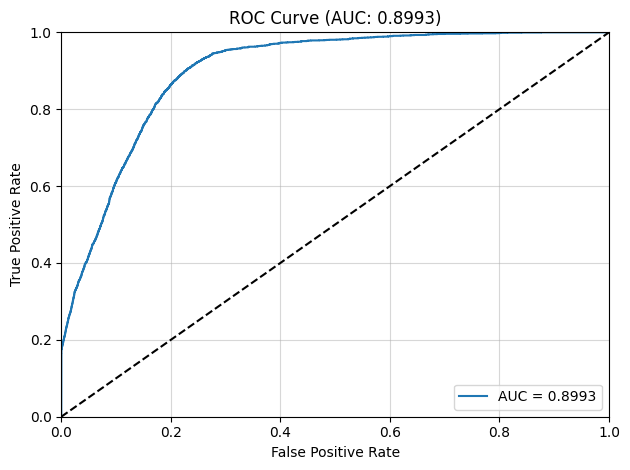

In [14]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], ls='--', color='k')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC: {auc:.4f})')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, axis='both', alpha=0.5)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-roc.png', dpi=150)
plt.show()

## Precision-Recall Curve

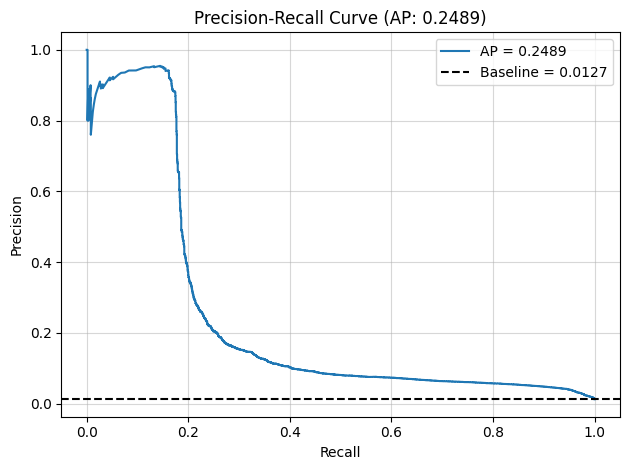

In [15]:
prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
baseline = np.mean(y_true)

plt.figure()
plt.plot(rec_curve, prec_curve, label=f'AP = {ap:.4f}')
plt.axhline(baseline, linestyle='--', color='k', label=f'Baseline = {baseline:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AP: {ap:.4f})')
plt.legend()
plt.grid(True, axis='both', alpha=0.5)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-pr.png', dpi=150)
plt.show()

## Gain & Lift Charts

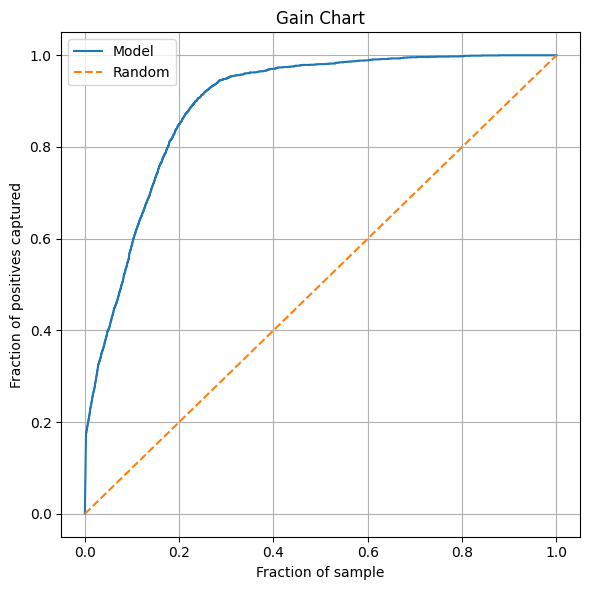

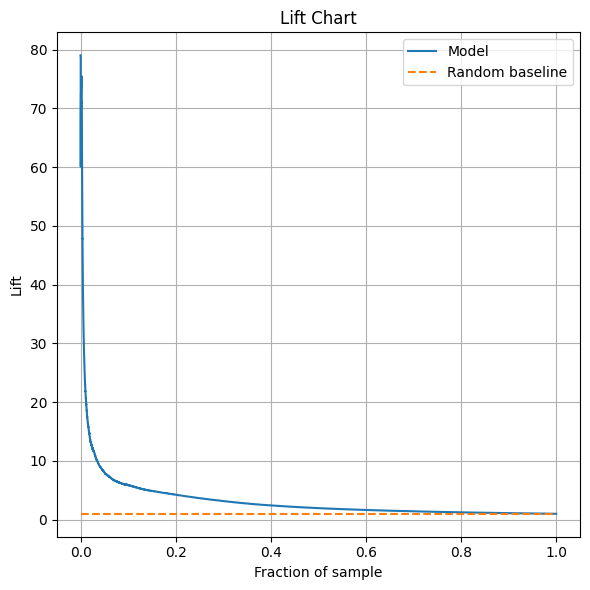

In [16]:
gl = pd.DataFrame({'y_test': y_true, 'y_prob': y_prob})
gl = gl.sort_values('y_prob', ascending=False).reset_index(drop=True)
gl['cum_positives'] = gl['y_test'].cumsum()
gl['gain']          = gl['cum_positives'] / gl['y_test'].sum()
gl['samples_frac']  = np.arange(1, len(gl) + 1) / len(gl)

# Gain chart
plt.figure(figsize=(6, 6))
plt.plot(gl['samples_frac'], gl['gain'], label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.xlabel('Fraction of sample')
plt.ylabel('Fraction of positives captured')
plt.title('Gain Chart')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-gain.png', dpi=150)
plt.show()

# Lift chart
gl['lift'] = gl['gain'] / gl['samples_frac']

plt.figure(figsize=(6, 6))
plt.plot(gl['samples_frac'], gl['lift'], label='Model')
plt.plot([0, 1], [1, 1], linestyle='--', label='Random baseline')
plt.xlabel('Fraction of sample')
plt.ylabel('Lift')
plt.title('Lift Chart')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-lift.png', dpi=150)
plt.show()

## KS Plot

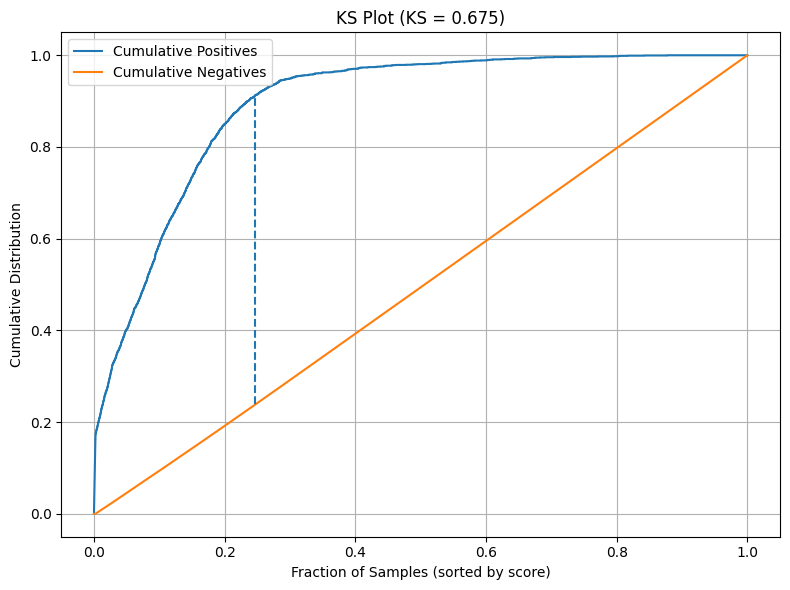

In [17]:
gl['neg']           = 1 - gl['y_test']
gl['cum_negatives'] = gl['neg'].cumsum()
gl['cum_pos_rate']  = gl['cum_positives'] / gl['cum_positives'].iloc[-1]
gl['cum_neg_rate']  = gl['cum_negatives'] / gl['cum_negatives'].iloc[-1]
gl['ks']            = gl['cum_pos_rate'] - gl['cum_neg_rate']

ks_value = gl['ks'].abs().max()
ks_idx   = gl['ks'].abs().idxmax()

plt.figure(figsize=(8, 6))
plt.plot(gl['samples_frac'], gl['cum_pos_rate'], label='Cumulative Positives')
plt.plot(gl['samples_frac'], gl['cum_neg_rate'], label='Cumulative Negatives')
plt.vlines(gl.loc[ks_idx, 'samples_frac'],
           gl.loc[ks_idx, 'cum_neg_rate'],
           gl.loc[ks_idx, 'cum_pos_rate'],
           linestyles='dashed')
plt.title(f'KS Plot (KS = {ks_value:.3f})')
plt.xlabel('Fraction of Samples (sorted by score)')
plt.ylabel('Cumulative Distribution')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'{PLOT_PREFIX}-ks.png', dpi=150)
plt.show()